# Hackathon 2 — ¿La escala cambia la historia?
## PCA con Palmer Penguins

**Integrantes:** Xavier Aranda y Andrés Proaño  
**Equipo:** Dragons AI

### Pregunta central

¿Cómo cambian las componentes principales y las conclusiones cuando las variables se usan en sus unidades originales o se estandarizan antes de aplicar PCA?

### Restricciones

- Trabajen con las cuatro mediciones numéricas indicadas.
- Calculen PCA con `numpy.linalg.svd`; no usen `sklearn.decomposition.PCA`.
- Escriban respuestas breves, pero deben citar resultados numéricos o elementos del gráfico.
- Ejecuten las celdas en orden. Al finalizar, reinicien el kernel y ejecuten todo.

## Plan sugerido — 90 minutos

| Etapa | Tiempo |
|---|---:|
| Auditoría y limpieza | 10 min |
| Predicción y preparación de matrices | 10 min |
| PCA con SVD y comparación de escalas | 25 min |
| Varianza explicada y cargas | 15 min |
| Visualización | 15 min |
| Reconstrucción, decisión y verificación | 15 min |

## 0. Preparación

Esta celda define las rutas y las cuatro variables. No modifiquen sus nombres.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = Path("data/penguins.csv")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

FEATURES = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]
LABEL = "species"

## Tarea 1. Auditar y limpiar los datos

1. Carguen el CSV, usando `NA` como valor faltante.
2. Comprueben el número de filas, las columnas y los faltantes de las cuatro mediciones.
3. Eliminen únicamente las filas que no tienen alguna de las cuatro mediciones o la especie.
4. Construyan `X` como una matriz `float` de tamaño `(n, 4)` y `species` como vector de etiquetas.

In [2]:
# TODO: completar sin cambiar los nombres de las variables finales.
df = pd.read_csv(DATA_PATH, na_values='NA')
missing_counts = df[FEATURES + [LABEL]].isnull().sum()
clean = df.dropna(subset=FEATURES + [LABEL])
X = clean[FEATURES].values.astype(float)
species = clean[LABEL].values

print("Forma original:", df.shape)
print("Faltantes por variable:")
print(missing_counts)
print("Forma limpia:", clean.shape)
print("Especies:")
print(pd.Series(species).value_counts())

Forma original: (344, 8)
Faltantes por variable:
bill_length_mm       2
bill_depth_mm        2
flipper_length_mm    2
body_mass_g          2
species              0
dtype: int64
Forma limpia: (342, 8)
Especies:
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64


### Respuesta 1

¿Cuántas filas se eliminaron y por qué este tratamiento es razonable para esta actividad? Indiquen también una limitación de eliminar filas incompletas.

**RESPUESTA AQUÍ**
Se eliminaron 2 filas ya que no esta completa la observación en esas dos filas en el dataset, esto respresenta el 0.58% por lo que el impacto en el tamaño de la muestra es mínimo y los datos restantes tienen una buena representación de las tres especies: Adelie, Gentoo y Chinstrap

## Tarea 2. Predecir el efecto de las unidades

Antes de calcular PCA, observen las unidades y los rangos de las cuatro variables. La masa corporal está en gramos; las otras variables están en milímetros.

### Respuesta 2 — predicción previa

¿Qué variable esperan que domine la primera componente si PCA se aplica a las variables solo centradas, sin estandarizar? Expliquen la razón.

**RESPUESTA AQUÍ**
Se espera que body_mass_g medida en gramos sea la variable que domine ya que en en términos absolutos es de mayor magnitud que las variables en milímetros.
En PCA la primera componente principal se orienta hacia la dirección de máxima varianza que en este caso es la variable que tiene la escala más grande.

## Tarea 3. Preparar dos versiones y calcular PCA con SVD

Construyan:

- `X_centered`: datos en unidades originales, con la media de cada columna restada;
- `Z`: datos estandarizados con media cero y desviación estándar muestral uno.

Implementen `pca_svd(A)`. Si

\[
A = U\Sigma V^T,
\]

las filas de `Vt` son las direcciones principales, las coordenadas son `U * s` y la proporción de varianza explicada se obtiene de `s**2 / sum(s**2)`.

In [3]:
def standardize(A):
    # TODO: devolver Z, mean y scale; usar ddof=1.
    mean = A.mean(axis=0)
    scale = A.std(axis=0, ddof=1)
    Z = (A - mean) / scale
    return Z, mean, scale


def pca_svd(A):
    # TODO: devolver scores, singular_values, components y explained_ratio.
    # components debe tener una componente por fila.
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    n = A.shape[0]
    
    # Coordenadas (scores)
    scores = U * s
    
    # Componentes (direcciones principales)
    components = Vt
    
    # Proporción de varianza explicada
    explained_ratio = (s**2) / (s**2).sum()
    
    return scores, s, components, explained_ratio


X_centered = X - X.mean(axis=0)
Z, mean, scale = standardize(X)

scores_raw, singular_raw, components_raw, ratio_raw = pca_svd(X_centered)
scores_std, singular_std, components_std, ratio_std = pca_svd(Z)

print("Media de Z:", Z.mean(axis=0))
print("Desviación estándar de Z:", Z.std(axis=0, ddof=1))

Media de Z: [ 8.31044135e-17  4.15522068e-16 -8.31044135e-16  1.24656620e-16]
Desviación estándar de Z: [1. 1. 1. 1.]


## Tarea 4. Comparar varianza explicada y cargas

1. Presenten una tabla con la proporción y la proporción acumulada para las cuatro componentes, tanto sin estandarizar como estandarizando.
2. Presenten las cargas de la primera componente en ambos casos. Usen valores absolutos para identificar qué variable pesa más; el signo de una componente puede invertirse sin cambiar PCA.
3. Calculen el menor número `k90` de componentes estandarizadas que conserva al menos 90% de la varianza.

In [4]:
# TODO: construir summary y loadings_pc1.
# Crear tabla de varianza explicada
summary = pd.DataFrame({
    'PC': ['PC1', 'PC2', 'PC3', 'PC4'],
    'Raw - Proporción': ratio_raw,
    'Raw - Acumulada': np.cumsum(ratio_raw),
    'Estandarizado - Proporción': ratio_std,
    'Estandarizado - Acumulada': np.cumsum(ratio_std)
})

# Cargas de la primera componente (valores absolutos)
loadings_pc1 = pd.DataFrame({
    'Variable': FEATURES,
    'Raw (PC1)': np.abs(components_raw[0]),
    'Estandarizado (PC1)': np.abs(components_std[0])
})

# Menor número de componentes para 90% de varianza acumulada
k90 = np.argmax(np.cumsum(ratio_std) >= 0.90) + 1

display(summary)
display(loadings_pc1)
print("Componentes necesarias para al menos 90%:", k90)

,PC,Raw - Proporción,Raw - Acumulada,Estandarizado - Proporción,Estandarizado - Acumulada
0,PC1,0.999891,0.999891,0.688439,0.688439
1,PC2,0.000080,0.999971,0.193129,0.881568
2,PC3,0.000025,0.999996,0.091309,0.972877
3,PC4,0.000004,1.000000,0.027123,1.000000


,Variable,Raw (PC1),Estandarizado (PC1)
0,bill_length_mm,0.004051,0.455250
1,bill_depth_mm,0.001162,0.400335
2,flipper_length_mm,0.015275,0.576013
3,body_mass_g,0.999874,0.548350


Componentes necesarias para al menos 90%: 3


### Respuesta 3

¿La predicción previa se confirmó? Justifiquen con la proporción de varianza de PC1 y con la carga dominante en el caso no estandarizado.

**RESPUESTA AQUÍ**
el PC1 explica 99.99% de la varianza total. Esto demuestra que prácticamente toda la variación en los datos centrados se capturan en una unica dirección.
Se confirma que la variable dominante es body_mass_g que tiene una carga de 0.9999 en PC1 mientras que las otras variables tienen cargas que son practicamente nulas.

### Respuesta 4

En el PCA estandarizado, ¿qué combinación de rasgos representa PC1? No enumeren únicamente números: describan el contraste o patrón biológico que sugieren las cargas.

**RESPUESTA AQUÍ**
Estos rasgos representan que un pinguino se puede describir basicamente con su tamaño corporal, es decir si con valores altos en PC1 (body_mass) el pinguino es más grande en todas sus dimensiones: Aletas más largas, mas pesados, un pico mas largo y profundo, por lo contrario un valor bajo de PC1 corresponde a un pinguino más pequeño en dichas características.

### Respuesta 5

¿Dos componentes cumplen el criterio de conservar al menos 90%? Indiquen la proporción acumulada y el valor de `k90`.

**RESPUESTA AQUÍ**
No, 2 componentes no cumplen el criterio. PC1 68.84%, PC1+PC2 88.16%, PC1+PC2+PC3 97.29%. 
Con 2 componentes solo conservamos el 88.16% de la varianza, es necesario agregar un tercer componente para alcanzar más del 90%.

## Tarea 5. Visualizar las dos representaciones

Construyan una figura con dos paneles PC1–PC2, coloreados por especie:

- panel izquierdo: datos centrados, sin estandarizar;
- panel derecho: datos estandarizados.

Incluyan etiquetas, leyenda, porcentaje de varianza explicado por cada eje y un título. Guarden la figura como `output/pca_penguins.png`.

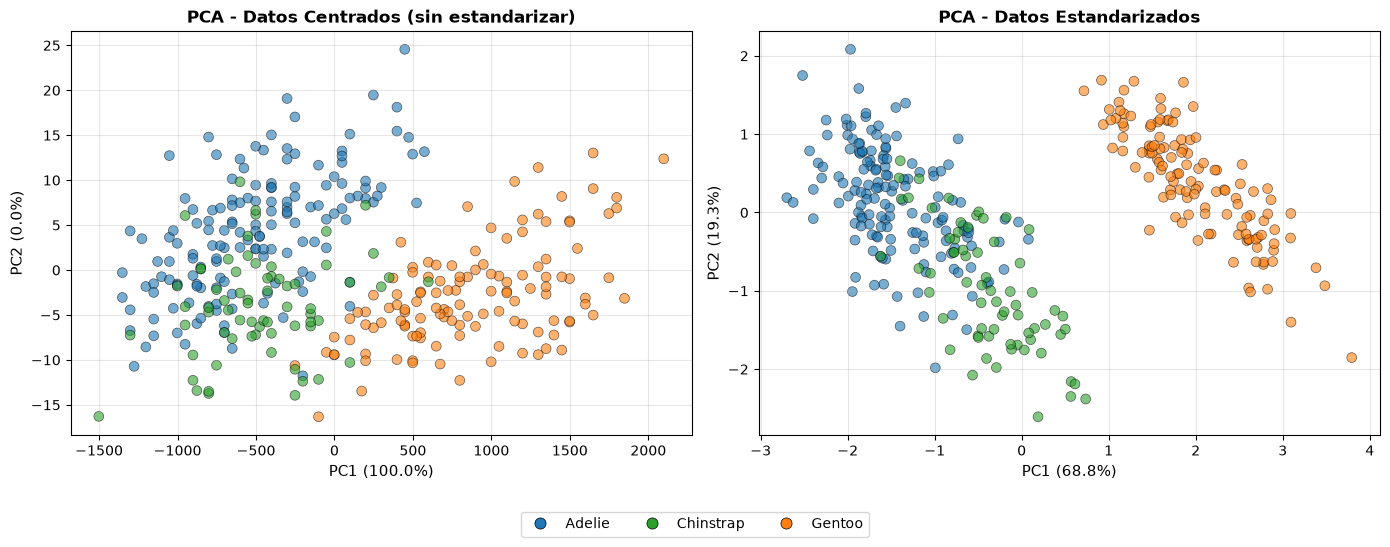

Figura guardada en: output/pca_penguins.png


In [5]:
# TODO: crear los dos paneles y guardar la figura.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mapa de colores para las especies
colors = {'Adelie': '#1f77b4', 'Gentoo': '#ff7f0e', 'Chinstrap': '#2ca02c'}
color_map = [colors[s] for s in species]

# Panel izquierdo: datos centrados sin estandarizar
ax0 = axes[0]
scatter0 = ax0.scatter(scores_raw[:, 0], scores_raw[:, 1], c=color_map, s=50, alpha=0.6, edgecolors='k', linewidth=0.5)
ax0.set_xlabel(f'PC1 ({ratio_raw[0]:.1%})', fontsize=11)
ax0.set_ylabel(f'PC2 ({ratio_raw[1]:.1%})', fontsize=11)
ax0.set_title('PCA - Datos Centrados (sin estandarizar)', fontsize=12, fontweight='bold')
ax0.grid(True, alpha=0.3)

# Panel derecho: datos estandarizados
ax1 = axes[1]
scatter1 = ax1.scatter(scores_std[:, 0], scores_std[:, 1], c=color_map, s=50, alpha=0.6, edgecolors='k', linewidth=0.5)
ax1.set_xlabel(f'PC1 ({ratio_std[0]:.1%})', fontsize=11)
ax1.set_ylabel(f'PC2 ({ratio_std[1]:.1%})', fontsize=11)
ax1.set_title('PCA - Datos Estandarizados', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Leyenda común
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[sp], markersize=8, label=sp, markeredgecolor='k', markeredgewidth=0.5) for sp in sorted(colors.keys())]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True, fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pca_penguins.png', dpi=100, bbox_inches='tight')
plt.show()

print("Figura guardada en:", OUTPUT_DIR / 'pca_penguins.png')

### Respuesta 6

¿Qué diferencias observan entre las dos representaciones? ¿Las especies quedan perfectamente separadas? Citen al menos un patrón visible y eviten afirmar que PCA es un clasificador.

**RESPUESTA AQUÍ**

## Tarea 6. Reconstruir y medir la pérdida

Reconstruyan los datos estandarizados con dos componentes:

\[
\widehat{Z}_2 = T_2 V_2^T.
\]

Luego vuelvan a las unidades originales y calculen:

- error relativo de Frobenius en el espacio estandarizado;
- RMSE por variable en sus unidades originales.

Verifiquen además que

\[
\frac{\lVert Z-\widehat{Z}_2\rVert_F}{\lVert Z\rVert_F}
= \sqrt{1-\text{varianza acumulada con 2 componentes}}.
\]

In [6]:
# TODO: reconstruir, calcular errores y construir rmse_by_feature.
# Reconstrucción con k=2 componentes en el espacio estandarizado
k = 2
T_2 = scores_std[:, :k]  # Primeras k componentes de scores
V_2 = components_std[:k, :]  # Primeras k componentes

Z_hat_2 = T_2 @ V_2  # Reconstrucción en espacio estandarizado

# Volver a unidades originales
X_hat_2 = Z_hat_2 * scale + mean

# Error relativo de Frobenius en espacio estandarizado
frobenius_z = np.linalg.norm(Z - Z_hat_2, 'fro')
frobenius_z_total = np.linalg.norm(Z, 'fro')
relative_error_2 = frobenius_z / frobenius_z_total

# Error teórico calculado desde varianza acumulada
theoretical_error_2 = np.sqrt(1 - np.cumsum(ratio_std)[k-1])

# RMSE por variable en unidades originales
rmse_by_variable = []
for i in range(X.shape[1]):
    mse = np.mean((X[:, i] - X_hat_2[:, i]) ** 2)
    rmse = np.sqrt(mse)
    rmse_by_variable.append({'Variable': FEATURES[i], 'RMSE': rmse})

rmse_by_feature = pd.DataFrame(rmse_by_variable)

print("Error relativo k=2:", relative_error_2)
print("Error teórico k=2:", theoretical_error_2)
display(rmse_by_feature)

Error relativo k=2: 0.3441395510003709
Error teórico k=2: 0.3441395510003709


,Variable,RMSE
0,bill_length_mm,2.138775
1,bill_depth_mm,0.510444
2,flipper_length_mm,4.125416
3,body_mass_g,326.735408


### Respuesta 7 — decisión final

El equipo debe comunicar los datos en un gráfico 2D, pero el análisis interno exige conservar al menos 90% de la varianza. ¿Qué preprocesamiento y cuántas componentes recomiendan para cada propósito? Justifiquen con la varianza acumulada, las cargas, el gráfico y el error de reconstrucción.

**RESPUESTA AQUÍ**

## Tarea 7. Verificación pública

La celda debe terminar sin errores. Estas comprobaciones no reemplazan las respuestas escritas.

In [7]:
assert df.shape == (344, 8)
assert clean.shape[0] == 342
assert X.shape == (342, 4)
assert np.isfinite(X).all()
assert np.allclose(Z.mean(axis=0), 0.0, atol=1e-12)
assert np.allclose(Z.std(axis=0, ddof=1), 1.0, atol=1e-12)
assert np.allclose(components_std @ components_std.T, np.eye(4), atol=1e-10)
assert np.isclose(ratio_raw.sum(), 1.0)
assert np.isclose(ratio_std.sum(), 1.0)
assert np.cumsum(ratio_std)[k90 - 1] >= 0.90
assert k90 == 1 or np.cumsum(ratio_std)[k90 - 2] < 0.90
assert np.isclose(relative_error_2, theoretical_error_2, atol=1e-12)
assert (OUTPUT_DIR / "pca_penguins.png").exists()
print("VERIFICACIÓN PÚBLICA COMPLETA")

VERIFICACIÓN PÚBLICA COMPLETA
